# 05 MiniMind supervised fine-tuning

阶段 4 让模型学习了 next-token prediction；阶段 5 使用带有 `user` 与 `assistant` 角色的对话数据继续训练，使模型学会按照指令回答。

本 Notebook 解释并检查 SFT 数据流，再读取已经完成的训练产物；长训练命令统一放在阶段 README 中。读完后应能回答五个问题：

1. 一条对话怎样经过 chat template 变成 token sequence；
2. 为什么输入与 labels 都是 $[T]$，loss 却只计算 assistant response；
3. padding 与 truncation 会怎样影响 labels；
4. overfit100 与正式 64M 训练分别验证什么；
5. 一轮正式 SFT 后，validation、固定生成与七任务评估呈现了什么结果。

## 1. 加载固定配置与固定样本

下面读取阶段 5 已锁定的数据、tokenizer、配置和 split manifest。检查样本固定为 seed 42 产生的第一个 inspection row。

先用一个简化例子说明。假设 Dataset 的固定长度是 8，原始对话是 user 问“2+2 等于几”，assistant 回答“4”。为便于观察，`[USER]` 和 `[ASSISTANT]` 各写成一个 role marker；真实 tokenizer 可能把 role marker 切成多个 token ID。

```text
position:   0       1        2      3            4     5      6    7
input_ids: [USER]  2+2=?   [END]  [ASSISTANT]    4   [END]   PAD  PAD
labels:    -100    -100    -100       -100       4   [END]  -100 -100
```

这条样本的四个字段是：

- `sequence_length=8`：Dataset 最终输出 8 个位置；
- `unpadded_length=6`：前 6 个位置是真实对话，后 2 个位置是 PAD；
- `supervised next-token targets=2`：只有回答“4”和 assistant end marker 参与 loss；
- `truncated=False`：真实对话只占 6 个位置，没有超过固定长度 8。

模型在位置 $p$ 输出 logits，用来预测位置 $p+1$ 的 token。上面的 arrays 因此按下面方式进入 loss：

| logits 位置 | 当前 input token | 要预测的下一个 token | 使用的 label | 计算 loss |
| ---: | --- | --- | ---: | --- |
| 0 | `[USER]` | `2+2=?` | `-100` | 否 |
| 1 | `2+2=?` | `[END]` | `-100` | 否 |
| 2 | `[END]` | `[ASSISTANT]` | `-100` | 否 |
| 3 | `[ASSISTANT]` | `4` | `token_id(4)` | 是 |
| 4 | `4` | assistant `[END]` | `token_id([END])` | 是 |
| 5 | assistant `[END]` | `PAD` | `-100` | 否 |
| 6 | `PAD` | `PAD` | `-100` | 否 |

8 个 input positions 只产生 7 次 next-token prediction，因为最后一个位置没有位于它右侧的 token 可供预测。7 个 targets 中，2 个参与 loss，另外 3 个非 PAD targets 和 2 个 PAD targets 被忽略。下面再读取真实固定样本，四个字段的含义完全相同。

In [1]:
from dataclasses import replace
from html import escape
from pathlib import Path
import inspect
import json
import statistics

import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

from llm_learning.minimind.convert import verify_conversion
from llm_learning.minimind.sft_config import load_sft_config
from llm_learning.minimind.sft_data import (
    MiniMindSFTDataset,
    assistant_marker_ids,
    create_token_inspection,
    encode_sft_sample,
    load_sft_json_dataset,
)
from llm_learning.minimind.sft_train import run_sft_training

# 从项目根目录读取已经锁定的数据与配置。
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

config_path = ROOT / "docs/stages/05_sft/configs/overfit100.json"
manifest_path = ROOT / "outputs/minimind/stage5/overfit100/data_manifest.json"
config = load_sft_config(config_path)
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
records = load_sft_json_dataset(ROOT / config.data_path)
tokenizer = AutoTokenizer.from_pretrained(ROOT / config.source_dir / "model")

row_id = manifest["split"]["inspection_row_ids"][0]
sample = encode_sft_sample(records[row_id], row_id, tokenizer, config)

print(f"dataset rows: {len(records):,}")
print(f"fixed row_id: {row_id}")
padding_tokens = config.sequence_length - sample["unpadded_length"]
non_padding_targets = max(sample["unpadded_length"] - 1, 0)
ignored_non_padding_targets = non_padding_targets - sample["supervised_tokens"]
shifted_target_positions = config.sequence_length - 1

print("input positions:")
print(f"  sequence_length: {config.sequence_length}")
print(f"  = non-PAD tokens: {sample['unpadded_length']}")
print(f"  + PAD tokens: {padding_tokens}")
print("shifted target positions:")
print(f"  total: {shifted_target_positions}")
print(f"  = supervised next-token targets: {sample['supervised_tokens']}")
print(f"  + ignored non-PAD targets: {ignored_non_padding_targets}")
print(f"  + ignored PAD targets: {padding_tokens}")
print(f"truncated: {sample['truncated']}")

dataset rows: 905,718
fixed row_id: 82374
input positions:
  sequence_length: 768
  = non-PAD tokens: 570
  + PAD tokens: 198
shifted target positions:
  total: 767
  = supervised next-token targets: 541
  + ignored non-PAD targets: 28
  + ignored PAD targets: 198
truncated: False


## 2. 从 messages 到 prompt

一条原始 `conversations` 记录不会直接交给模型，而是依次经过下面的转换：

```text
conversations → messages → chat template 渲染的 prompt → input_ids 与 labels
```

本节只检查中间的 `messages → prompt`：chat template 将角色、正文和结束标记拼成一段文本。下一节再检查 tokenizer 怎样把这段 prompt 转成 `input_ids`，以及哪些位置在 labels 中保留真实 token ID。

这里显示的 messages 已完成两项可复现的数据增强：部分样本加入 system prompt，部分 assistant response 去掉空的 think block。两项选择都由固定 seed 和 row ID 决定，因此重复运行会得到相同结果。

固定样本的回答较长，下面只直接显示 user 与 assistant 的边界。完整 messages 和完整 prompt 放在折叠区域中，需要时可以展开检查。

In [2]:
# 先突出 chat template 插入的角色边界，再保留可展开的完整文本。
prompt = sample["prompt"]
assistant_boundary = prompt.index("<|im_start|>assistant")
boundary_text = prompt[max(0, assistant_boundary - 90) : assistant_boundary + 130]
print("user -> assistant 边界:")
print(boundary_text)

messages_text = escape(json.dumps(sample["messages"], ensure_ascii=False, indent=2))
prompt_text = escape(prompt)
display(HTML(
    "<details><summary>完整 messages</summary>"
    f"<pre style='max-height:360px;overflow:auto'>{messages_text}</pre></details>"
    "<details><summary>完整 chat template 输出</summary>"
    f"<pre style='max-height:360px;overflow:auto'>{prompt_text}</pre></details>"
))

user -> assistant 边界:
<|im_start|>user
请给我写一篇关于“人工智能在医疗领域的应用”主题的短文。<|im_end|>
<|im_start|>assistant
《人工智能在医疗领域的应用》

随着科技的飞速发展，人工智能技术逐渐渗透到各个领域，医疗行业也不例外。人工智能在医疗领域的应用，不仅提高了医疗服务的效率，还为疾病的预防、诊断和治疗提供了新的可能，极大地推动了医疗行业


## 3. response mask：哪些 token 参与 loss

Dataset 返回的 `input_ids` 与 labels shape 都是 $[T]$，而且相同位置仍对应同一个 token：

- `input_ids` 包含 system、user、assistant 和 padding，供模型完成整次 forward；
- labels 在不应计入 loss 的位置写入 `-100`；PyTorch cross entropy 会忽略这些位置；
- assistant 正文以及紧随其后的结束标记保留真实 token id，因此参与 loss；
- assistant role marker 本身不参与 loss；assistant 正文和结束标记参与 loss。

一个简化样本在 Dataset 中可以表示为：

```text
input_ids: [user_token, assistant_marker, A1, A2, EOS, PAD]
labels:    [-100,      -100,             A1, A2, EOS, -100]
```

Dataset 没有把 labels 提前左移。MiniMind forward 才执行 causal shift：位置 $p$ 的 logits 与 `labels[p + 1]` 比较。因此下表同时显示当前位置保存的 `labels[p]` 和真正用于当前位置预测的 `labels[p + 1]`。

MiniMind 使用 ByteLevel BPE，也就是先按字节处理文本再执行 BPE。一个中文字符可能由相邻的多个 token ID 共同编码。表中的 token text 来自 tokenizer 返回的原文 offset；offset 采用左闭右开区间，start 是起始字符位置，end 是不包含在范围内的结束位置。

In [3]:
# 先查看 user/assistant 边界，再保留完整的非 PAD token 表。
rows = create_token_inspection(sample, tokenizer)

def token_text(value):
    return escape(repr(value))

def render_token_table(table_rows):
    header = (
        "<tr><th>position p</th><th>input text</th><th>input offset</th><th>input id</th>"
        "<th>input segment</th><th>labels[p]</th><th>next text</th>"
        "<th>next offset</th><th>next id</th><th>next segment</th><th>labels[p + 1]</th>"
        "<th>computes loss</th></tr>"
    )
    body = "".join(
        "<tr>"
        f"<td>{row['position']}</td>"
        f"<td><code>{token_text(row['input_token'])}</code></td>"
        f"<td>{row['input_offset']}</td>"
        f"<td>{row['input_token_id']}</td>"
        f"<td>{escape(row['input_segment'])}</td>"
        f"<td>{row['stored_label']}</td>"
        f"<td><code>{token_text(row['next_token'])}</code></td>"
        f"<td>{row['next_offset']}</td>"
        f"<td>{row['next_token_id']}</td>"
        f"<td>{escape(row['next_segment'])}</td>"
        f"<td>{row['shifted_target']}</td>"
        f"<td>{row['computes_loss']}</td>"
        "</tr>"
        for row in table_rows
    )
    return (
        "<div style='max-height:520px;overflow:auto'>"
        "<table style='font-size:13px'>" + header + body + "</table></div>"
    )

boundary_rows = [row for row in rows if 20 <= row["position"] <= 34]
display(HTML("<h4>角色边界</h4>" + render_token_table(boundary_rows)))
display(HTML(
    "<details><summary>完整非 PAD token 表</summary>"
    + render_token_table(rows)
    + "</details>"
))

position p,input text,input offset,input id,input segment,labels[p],next text,next offset,next id,next segment,labels[p + 1],computes loss
20,'文',"(43, 44)",574,user,-100,'。',"(44, 45)",302,user,-100,False
21,'。',"(44, 45)",302,user,-100,'<|im_end|>',"(45, 55)",2,user,-100,False
22,'<|im_end|>',"(45, 55)",2,user,-100,'\n',"(55, 56)",234,user,-100,False
23,'\n',"(55, 56)",234,user,-100,'<|im_start|>',"(56, 68)",1,assistant_marker,-100,False
24,'<|im_start|>',"(56, 68)",1,assistant_marker,-100,'ass',"(68, 71)",1388,assistant_marker,-100,False
25,'ass',"(68, 71)",1388,assistant_marker,-100,'ist',"(71, 74)",570,assistant_marker,-100,False
26,'ist',"(71, 74)",570,assistant_marker,-100,'ant',"(74, 77)",811,assistant_marker,-100,False
27,'ant',"(74, 77)",811,assistant_marker,-100,'\n',"(77, 78)",234,assistant_marker,-100,False
28,'\n',"(77, 78)",234,assistant_marker,-100,'《',"(78, 79)",1582,assistant_response,1582,True
29,'《',"(78, 79)",1582,assistant_response,1582,'人工智能',"(79, 83)",2225,assistant_response,2225,True


position p,input text,input offset,input id,input segment,labels[p],next text,next offset,next id,next segment,labels[p + 1],computes loss
0,'<|im_start|>',"(0, 12)",1,user,-100,'us',"(12, 14)",832,user,-100,False
1,'us',"(12, 14)",832,user,-100,'er',"(14, 16)",311,user,-100,False
2,'er',"(14, 16)",311,user,-100,'\n',"(16, 17)",234,user,-100,False
3,'\n',"(16, 17)",234,user,-100,'请',"(17, 18)",960,user,-100,False
4,'请',"(17, 18)",960,user,-100,'给我',"(18, 20)",3530,user,-100,False
5,'给我',"(18, 20)",3530,user,-100,'写',"(20, 21)",1226,user,-100,False
6,'写',"(20, 21)",1226,user,-100,'一',"(21, 22)",349,user,-100,False
7,'一',"(21, 22)",349,user,-100,'篇',"(22, 23)",4215,user,-100,False
8,'篇',"(22, 23)",4215,user,-100,'关于',"(23, 25)",1956,user,-100,False
9,'关于',"(23, 25)",1956,user,-100,'“',"(25, 26)",683,user,-100,False


In [4]:
# 按 next-token 所在区段解释哪些预测实际参与 loss。
segment_summary = {}
for row in rows:
    segment = row["next_segment"]
    counters = segment_summary.setdefault(segment, {"targets": 0, "loss_tokens": 0})
    counters["targets"] += 1
    counters["loss_tokens"] += int(row["computes_loss"])

print("按 next-token segment 汇总:")
for segment, counters in segment_summary.items():
    print(f"{segment:>24}: {counters}")

按 next-token segment 汇总:
                    user: {'targets': 23, 'loss_tokens': 0}
        assistant_marker: {'targets': 5, 'loss_tokens': 0}
      assistant_response: {'targets': 539, 'loss_tokens': 539}
    assistant_end_marker: {'targets': 2, 'loss_tokens': 2}


需要特别区分两件事：causal mask 限制每个位置只能关注当前位置及其左侧；response mask 决定哪些 target token 计入 loss。SFT 同时需要前者和后者，它们不互相替代。

## 4. padding 与 truncation

固定样本经过 tokenization 后包含 570 个真实 token。Dataset 必须把每条样本整理成配置指定的固定长度，因此只有两种处理：

- 固定长度大于真实长度：在右侧补 PAD；
- 固定长度小于真实长度：从右侧截断。

下面对同一条样本做两次处理。正式配置的长度是 768，因此得到 `570 个真实 token + 198 个 PAD = 768 个位置`。为了直观看到截断，演示单元临时使用长度 128；正式训练配置仍为 768。

In [5]:
# 对比正式的 padding 与人为缩短长度后的 truncation。
tensor_dataset = MiniMindSFTDataset(records, [row_id], tokenizer, config)
tensor_sample = tensor_dataset[0]
batch = next(iter(DataLoader(tensor_dataset, batch_size=1)))
padding_positions = tensor_sample["input_ids"].eq(tokenizer.pad_token_id)
padding_labels_ignored = tensor_sample["labels"][padding_positions].eq(-100).all().item()

short_config = replace(config, sequence_length=128)
short_sample = encode_sft_sample(records[row_id], row_id, tokenizer, short_config)
complete_active_labels = [label for label in sample["labels"] if label != -100]
short_active_labels = [label for label in short_sample["labels"] if label != -100]
_, assistant_end_ids = assistant_marker_ids(tokenizer)
complete_has_end = complete_active_labels[-len(assistant_end_ids) :] == assistant_end_ids
short_has_end = short_active_labels[-len(assistant_end_ids) :] == assistant_end_ids
discarded_tokens = sample["unpadded_length"] - len(short_sample["input_ids"])

print("原始对话")
print(f"  真实 token: {sample['unpadded_length']}")
print()
print(f"A. 正式配置: sequence_length={config.sequence_length}")
print("  处理: 右侧补 PAD")
print(
    f"  结果: {sample['unpadded_length']} 个真实 token + "
    f"{padding_positions.sum().item()} 个 PAD = {config.sequence_length} 个位置"
)
print(f"  参与 loss: {sample['supervised_tokens']} 个 assistant tokens")
print(f"  保留 EOS: {complete_has_end}")
print(
    f"  {padding_positions.sum().item()} 个 PAD labels 全是 -100: "
    f"{padding_labels_ignored}"
)
print()
print(f"B. 截断演示: sequence_length={short_config.sequence_length}")
print("  处理: 从右侧截断")
print(
    f"  结果: 保留前 {len(short_sample['input_ids'])} 个，"
    f"截掉后 {discarded_tokens} 个真实 token"
)
print(f"  参与 loss: 剩余 {len(short_active_labels)} 个 assistant tokens")
print(f"  保留 EOS: {short_has_end}")
print()
print("正式配置的 Tensor shape")
print(f"单条 input_ids: {tuple(tensor_sample['input_ids'].shape)}")
print(f"单条 labels:    {tuple(tensor_sample['labels'].shape)}")
print(f"1 条组成 batch: {tuple(batch['input_ids'].shape)}")

原始对话
  真实 token: 570

A. 正式配置: sequence_length=768
  处理: 右侧补 PAD
  结果: 570 个真实 token + 198 个 PAD = 768 个位置
  参与 loss: 541 个 assistant tokens
  保留 EOS: True
  198 个 PAD labels 全是 -100: True

B. 截断演示: sequence_length=128
  处理: 从右侧截断
  结果: 保留前 128 个，截掉后 442 个真实 token
  参与 loss: 剩余 99 个 assistant tokens
  保留 EOS: False

正式配置的 Tensor shape
单条 input_ids: (768,)
单条 labels:    (768,)
1 条组成 batch: (1, 768)


第一行是实际训练行为：570 个真实 token 全部保留，右侧补 198 个 PAD；`input_ids` 和 labels 都有 768 个位置，DataLoader 再加入 batch 维度后得到 `(1, 768)`。所有 PAD labels 都是 `-100`，因此不参与 loss。

第二行只演示 truncation：570 个真实 token 只能保留前 128 个，后 442 个被截掉。留下的 99 个 assistant tokens 仍参与 loss，但位于回答末尾的 EOS 已经丢失，因此这条截断样本不能提供“何时停止回答”的完整监督。

Dataset 返回 `truncated` 和 `supervised_tokens`，就是为了在训练前发现 EOS 被截断或没有有效 response label 的样本。

本项目使用 right padding，PAD 只出现在有效文本之后。causal mask 使前面的有效 token 无法关注后面的 PAD，PAD labels 又全部是 `-100`，所以训练 forward 无需额外传入 padding mask。

## 5. Pretrain 与 SFT：相同训练循环，不同监督信号

Full SFT 没有增加新的模型层。本项目加载阶段 4 的 64M pretrained weights，然后继续更新同一组参数。两者都使用 next-token cross entropy、backward 和 AdamW，主要区别在输入数据以及哪些 labels 参与 loss。

| 项目 | Pretrain | Full SFT |
| --- | --- | --- |
| 初始权重 | 随机初始化 | 阶段 4 pretrained weights |
| 数据文件 | `pretrain_t2t_mini.jsonl` | `sft_t2t_mini.jsonl` |
| 文件大小 | 1.16 GiB | 1.62 GiB |
| 总记录数 | 1,270,238 | 905,718 |
| 正式 train / validation | 1,268,190 / 2,048 | 903,670 / 2,048 |
| 输入形式 | 普通文本 | conversations 经 chat template 渲染 |
| 参与 loss 的 labels | 几乎全部非 PAD tokens | assistant response 与 EOS |
| sequence length | 340 | 768 |
| learning rate | `5e-4` | `1e-5` |
| 参数更新 | 全部 63,912,192 个参数 | 继续更新全部 63,912,192 个参数 |
| 直接目标 | 学习文本中的语言与模式 | 学习根据对话上下文回答指令 |

SFT 的单次参数更新仍沿用阶段 4 的训练主循环，只是 Dataset 改为下面的数据流：

```text
messages
   -> chat template
   -> input_ids + 经过 response mask 处理的 labels
   -> MiniMind forward
   -> assistant response 与 EOS 上的 next-token cross entropy
   -> backward
   -> gradient clipping
   -> AdamW step
```

这里只延续模型权重；optimizer state、learning rate schedule 和 gradients 都在阶段 5 重新建立。

下一单元读取阶段 5 的真实入口代码，展示 SFT Dataset、split 和起始权重怎样接入阶段 4 的 `run_training`。

In [6]:
# 展示 SFT 对阶段 4 训练循环增加的实际参数。
print(inspect.getsource(run_sft_training))

def run_sft_training(
    config_path: Path,
    resume_path: Path | None = None,
    stop_after_step: int | None = None,
) -> dict[str, Any]:
    """从配置文件启动或恢复一次 SFT。"""
    config = load_sft_config(config_path)
    return run_training(
        config,
        resume_path,
        stop_after_step=stop_after_step,
        dataset_factory=build_sft_dataset,
        manifest_factory=create_sft_split_manifest,
        split_resolver=resolve_sft_split_row_ids,
        records_loader=load_sft_json_dataset,
        initial_weights_path=config.initial_weights_path,
    )



## 6. 两个实验各自回答什么

| 项目 | overfit100 | 正式 64M SFT |
|---|---:|---:|
| 固定训练样本 | 100 | 903,670 |
| validation 样本 | 与训练相同的 100 条 | 固定且独立的 2,048 条 |
| sequence length | 768 | 768 |
| batch size | 10 | 16 |
| 配置计划的 optimizer steps | 最多 1,000 | 112,960 |
| 目的 | 验证 labels、loss、backward 与 checkpoint 能连通 | 观察未见对话上的泛化能力 |

overfit100 的训练集与 evaluation 集相同，用来检查完整训练链路能否拟合固定样本；正式 64M SFT 使用独立 validation split，用来观察未见对话上的泛化能力。

In [7]:
# 读取正式配置；正式训练启动时会另外写入带哈希的 split manifest。
mini_config = load_sft_config(ROOT / "docs/stages/05_sft/configs/mini64.json")

print("按配置与固定划分规则推导的规模:")
print(f"overfit train/validation: {manifest['split']['train_count']}/{len(manifest['split']['validation_row_ids'])}")
print(f"mini64 train/validation: {len(records) - mini_config.validation_rows:,}/{mini_config.validation_rows:,}")
print(f"inspection rows: {manifest['split']['inspection_row_ids'][:5]} ...")

按配置与固定划分规则推导的规模:
overfit train/validation: 100/100
mini64 train/validation: 903,670/2,048
inspection rows: [82374, 232959, 319150, 780082, 156736] ...


## 7. 显存检查与执行边界

阶段初始化已用真实 64M pretrained weights、batch size 16、sequence length 768 和 BF16 完成一次 forward、backward、gradient clipping 与 AdamW step。峰值 allocated memory 约为 6.16 GiB，因此当前设备可以直接使用 batch size 16 和 `accumulation_steps=1`。

与阶段 4 相同，长训练由终端 CLI 执行，Notebook 负责解释数据流并读取训练产物。精确命令见 `docs/stages/05_sft/README.md`。

阶段 5 的训练与后续检查均已完成：`overfit100` 达到固定训练集 loss 阈值；`mini64` 完成一个 epoch 的 56,480 steps；随后完成固定生成、格式转换和七任务评估。后文直接读取这些实际产物。

## 8. 实际训练结果

下面从 `metrics.jsonl` 与 `summary.json` 读取训练结果。先区分三种 evaluation scope：

| scope | 数据 | 回答的问题 |
| --- | --- | --- |
| `train` / `train_full` | overfit100 使用的同一组 100 条训练样本 | 模型能否记住固定小数据 |
| `validation_subset` | 正式 validation 中固定的前 256 条 | 训练过程中泛化能力是否继续改善 |
| `validation_full` | 正式 validation 的完整 2,048 条 | 最终 checkpoint 在完整固定口径下的结果 |

周期曲线使用固定的 256 条 subset，最终结果使用完整 2,048 条 validation；解读时分别按各自口径比较。

### 两项训练的完成状态

| profile | planned steps | completed steps | completed epochs | stop reason | trained tokens | peak GiB | median train tokens/s |
| --- | ---: | ---: | ---: | --- | ---: | ---: | ---: |
| overfit100 | 1,000 | 180 | 18 | `overfit_loss_target` | 745,956 | 4.55 | 10,176 |
| mini64 | 112,960 | 56,480 | 1 | `stop_after_step` | 367,458,576 | 6.77 | 14,501 |

### overfit100 的固定训练集 evaluation

| optimizer step | fixed training-set loss | perplexity | evaluation tokens |
| ---: | ---: | ---: | ---: |
| 0 | 2.5488 | 12.792 | 41,442 |
| 20 | 2.1061 | 8.216 | 41,442 |
| 40 | 1.9094 | 6.749 | 41,442 |
| 60 | 1.7427 | 5.713 | 41,442 |
| 80 | 1.5893 | 4.900 | 41,442 |
| 100 | 1.4474 | 4.252 | 41,442 |
| 120 | 1.3169 | 3.732 | 41,442 |
| 140 | 1.1974 | 3.311 | 41,442 |
| 160 | 1.0869 | 2.965 | 41,442 |
| 180 | 0.9834 | 2.674 | 41,442 |

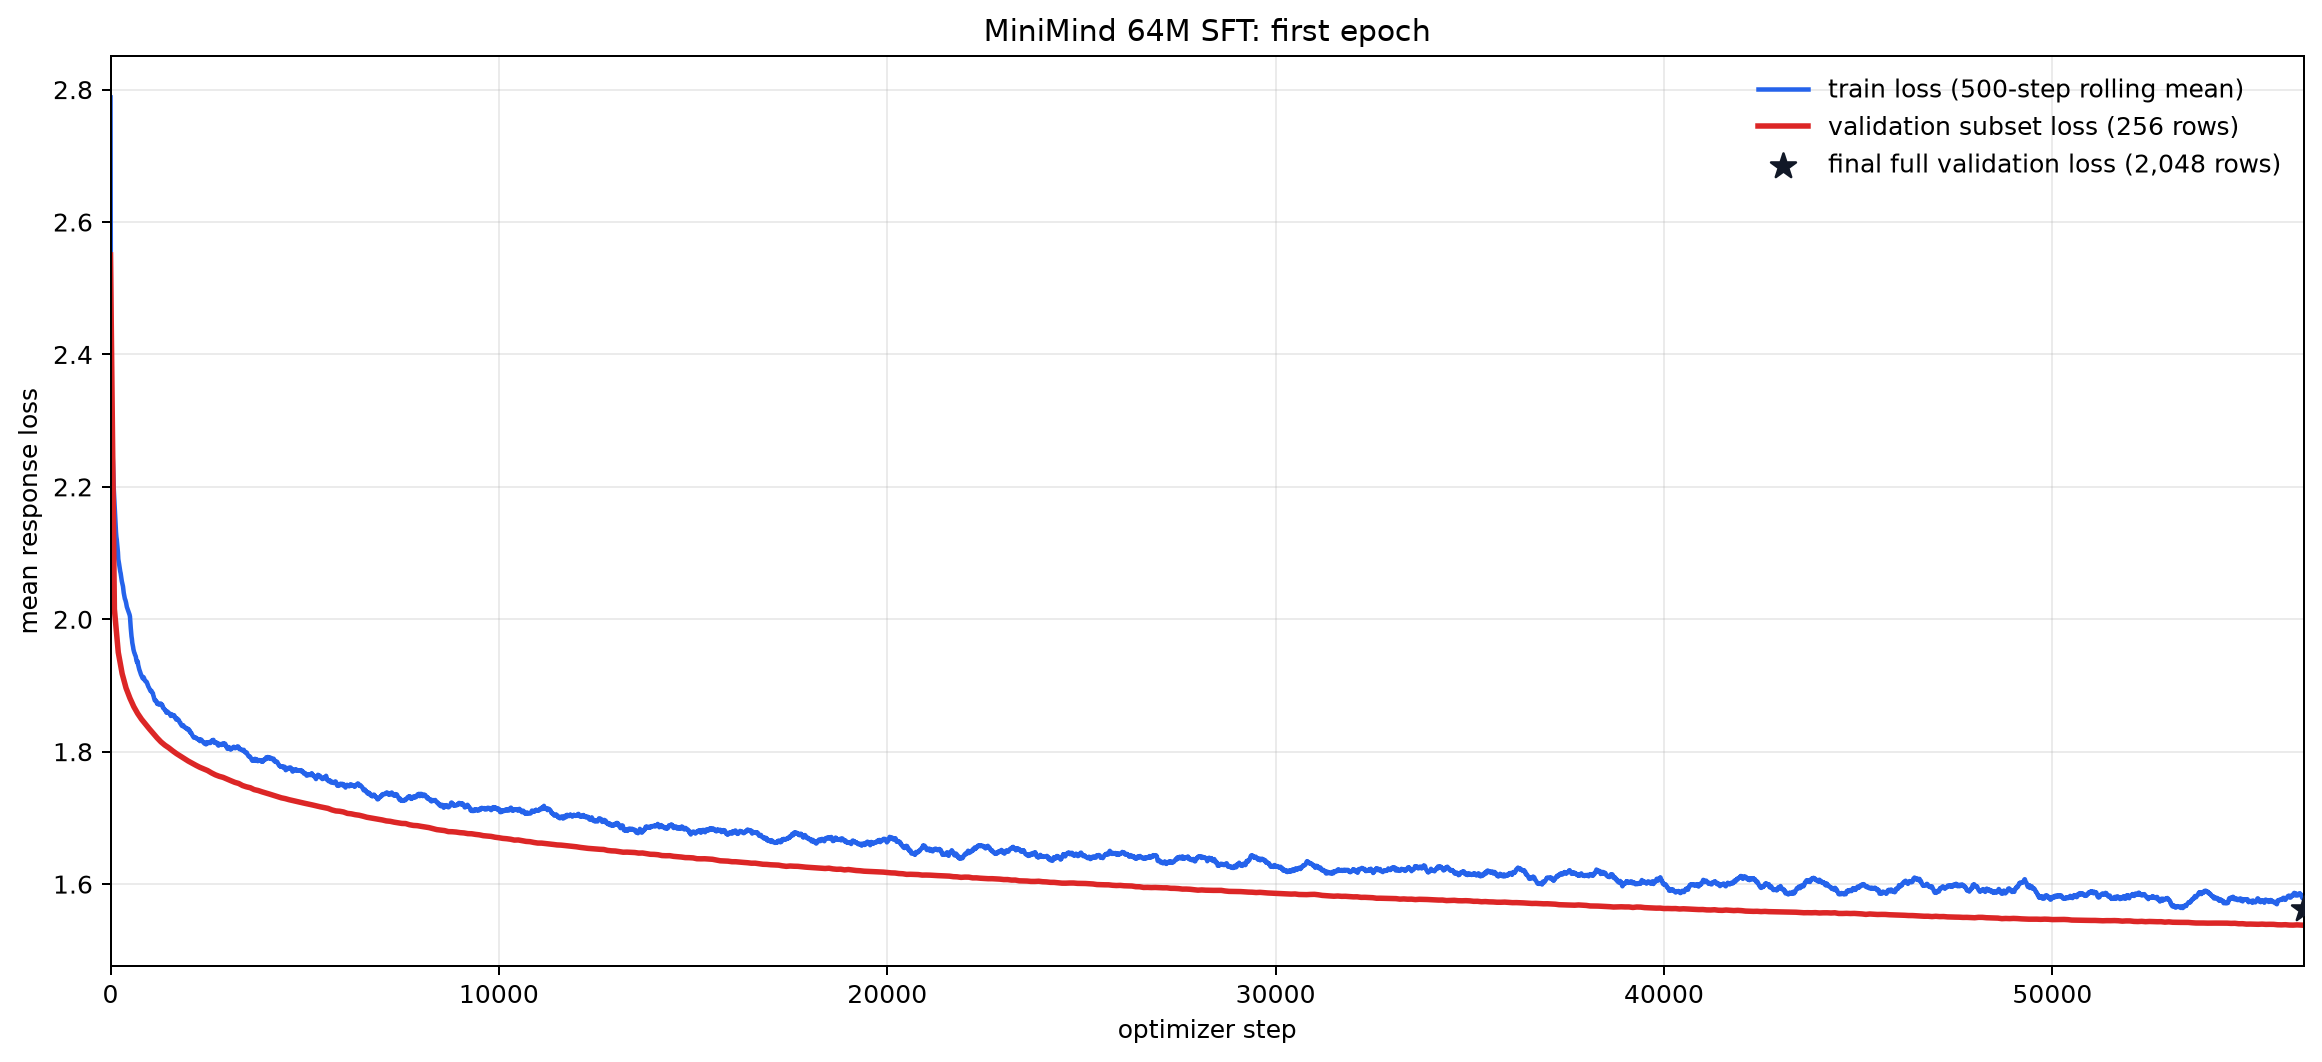

### 正式 SFT 的 validation

| optimizer step | evaluation set | loss | perplexity | evaluation tokens |
| ---: | --- | ---: | ---: | ---: |
| 0 | fixed 256-row subset | 2.5504 | 12.812 | 108,045 |
| 100 | fixed 256-row subset | 2.0153 | 7.503 | 108,045 |
| 1,000 | fixed 256-row subset | 1.8345 | 6.262 | 108,045 |
| 5,000 | fixed 256-row subset | 1.7221 | 5.596 | 108,045 |
| 10,000 | fixed 256-row subset | 1.6701 | 5.313 | 108,045 |
| 20,000 | fixed 256-row subset | 1.6176 | 5.041 | 108,045 |
| 30,000 | fixed 256-row subset | 1.5861 | 4.884 | 108,045 |
| 40,000 | fixed 256-row subset | 1.5631 | 4.774 | 108,045 |
| 50,000 | fixed 256-row subset | 1.5464 | 4.695 | 108,045 |
| 56,400 | fixed 256-row subset | 1.5381 | 4.656 | 108,045 |
| 56,480 | full 2,048-row validation | 1.5631 | 4.773 | 852,275 |

In [8]:
# 读取两项训练的实际指标，并展示固定训练集与 validation 结果。
def load_run_result(profile):
    output_dir = ROOT / "outputs/minimind/stage5" / profile
    summary = json.loads(
        (output_dir / "summary.json").read_text(encoding="utf-8")
    )
    metrics = [
        json.loads(line)
        for line in (output_dir / "metrics.jsonl").read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    ]
    return summary, metrics


overfit_summary, overfit_metrics = load_run_result("overfit100")
mini_summary, mini_metrics = load_run_result("mini64")

completion_rows = [
    "| profile | planned steps | completed steps | completed epochs | stop reason | trained tokens | peak GiB | median train tokens/s |",
    "| --- | ---: | ---: | ---: | --- | ---: | ---: | ---: |",
]
for profile, summary, metrics in [
    ("overfit100", overfit_summary, overfit_metrics),
    ("mini64", mini_summary, mini_metrics),
]:
    train_metrics = [row for row in metrics if row["kind"] == "train"]
    completion_rows.append(
        f"| {profile} | {summary['planned_optimizer_steps']:,} | "
        f"{summary['completed_optimizer_steps']:,} | "
        f"{summary['completed_epochs']} | `{summary['stop_reason']}` | "
        f"{summary['trained_tokens']:,} | "
        f"{summary['peak_memory_bytes'] / 2**30:.2f} | "
        f"{statistics.median(row['tokens_per_second'] for row in train_metrics):,.0f} |"
    )
display(Markdown("### 两项训练的完成状态\n\n" + "\n".join(completion_rows)))

overfit_evals = [
    row for row in overfit_metrics
    if row["kind"] == "eval" and row["scope"] == "train"
]
overfit_rows = [
    "| optimizer step | fixed training-set loss | perplexity | evaluation tokens |",
    "| ---: | ---: | ---: | ---: |",
]
for row in overfit_evals:
    overfit_rows.append(
        f"| {row['optimizer_step']:,} | {row['loss']:.4f} | "
        f"{row['perplexity']:.3f} | {row['tokens']:,} |"
    )
display(Markdown("### overfit100 的固定训练集 evaluation\n\n" + "\n".join(overfit_rows)))

mini_train = [row for row in mini_metrics if row["kind"] == "train"]
mini_periodic = [
    row for row in mini_metrics
    if row["kind"] == "eval" and row["scope"] == "validation_subset"
]
mini_final = next(
    row for row in reversed(mini_metrics)
    if row["kind"] == "eval" and row["scope"] == "validation_full"
)

rolling_window = 500
rolling_loss = []
rolling_sum = 0.0
for index, row in enumerate(mini_train):
    rolling_sum += row["loss"]
    if index >= rolling_window:
        rolling_sum -= mini_train[index - rolling_window]["loss"]
    rolling_loss.append(rolling_sum / min(index + 1, rolling_window))

plot_stride = 10
figure, axis = plt.subplots(figsize=(13, 6), dpi=180)
axis.plot(
    [row["optimizer_step"] for row in mini_train][::plot_stride],
    rolling_loss[::plot_stride],
    color="#2563eb", linewidth=1.8,
    label="train loss (500-step rolling mean)",
)
axis.plot(
    [row["optimizer_step"] for row in mini_periodic],
    [row["loss"] for row in mini_periodic],
    color="#dc2626", linewidth=2.2,
    label="validation subset loss (256 rows)",
)
axis.scatter(
    [mini_final["optimizer_step"]], [mini_final["loss"]],
    color="#111827", marker="*", s=110, zorder=3,
    label="final full validation loss (2,048 rows)",
)
axis.set_xlim(0, mini_summary["completed_optimizer_steps"])
axis.set_xlabel("optimizer step")
axis.set_ylabel("mean response loss")
axis.set_title("MiniMind 64M SFT: first epoch")
axis.grid(alpha=0.25, linewidth=0.8)
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

selected_steps = {0, 100, 1_000, 5_000, 10_000, 20_000, 30_000, 40_000, 50_000, 56_400}
validation_rows = [
    "| optimizer step | evaluation set | loss | perplexity | evaluation tokens |",
    "| ---: | --- | ---: | ---: | ---: |",
]
for row in mini_periodic:
    if row["optimizer_step"] not in selected_steps:
        continue
    validation_rows.append(
        f"| {row['optimizer_step']:,} | fixed 256-row subset | "
        f"{row['loss']:.4f} | {row['perplexity']:.3f} | "
        f"{row['tokens']:,} |"
    )
validation_rows.append(
    f"| {mini_final['optimizer_step']:,} | full 2,048-row validation | "
    f"{mini_final['loss']:.4f} | {mini_final['perplexity']:.3f} | "
    f"{mini_final['tokens']:,} |"
)
display(Markdown("### 正式 SFT 的 validation\n\n" + "\n".join(validation_rows)))

### overfit100 说明了什么

固定 100 条训练样本的 evaluation loss 从 2.5488 降到 0.9834，在第 18 个 epoch、180 个 optimizer steps 达到停止条件。这说明 response mask、loss、backward、optimizer 与 checkpoint 组成的训练链路能够拟合固定小数据。

### 正式一轮 SFT 说明了什么

正式训练完成 56,480 个 optimizer steps，正好遍历 903,670 条 train sequences 一轮，共处理 367,458,576 个 supervised response tokens。固定 256 条 validation subset 的 loss 从 2.5504 降到 1.5381，相对下降约 39.7%；perplexity 从 12.812 降到 4.656。完整 2,048 条 validation 的最终 loss 为 1.5631，perplexity 为 4.773。两个最终值接近，符合 subset 与完整集合的范围差异。

单个 batch 的 train loss 会随回答内容和有效 response token 数上下波动。500-step rolling mean 与固定 validation subset 总体同时下降，说明模型在这一轮训练中持续改善了同分布未见对话上的泛化能力。后半程 validation 仍缓慢下降，但边际改善已经明显小于训练早期，因此在一个 epoch 结束处停止并转向生成与下游评估。

正式配置原计划 2 epochs 和 112,960 steps，本次通过 `stop_after_step=56,480` 在第一轮结束时停止。summary 因而记录 `planned_optimizer_steps=112960`、`completed_optimizer_steps=56480` 和 `completed_epochs=1`。learning-rate schedule 仍按原计划的两轮计算，结束时 learning rate 约为 `5.5e-6`。

`checkpoints/minimind/stage5/mini64/latest.pt` 是包含 optimizer 与训练位置的 resume checkpoint；`weights_step_56480.pth` 是后续固定生成和格式转换使用的纯模型权重。

正式运行的 peak allocated GPU memory 为 6.77 GiB，训练日志中单 step tokens/s 的中位数约为 14,501。训练中途经过停止与 resume；summary 中的 `wall_time_seconds=11795.9` 记录最后一次运行，用于描述该次运行耗时。

训练后的固定生成、格式转换和七任务结果见下面三节。

## 9. 固定生成与格式转换

### 固定生成在检查什么

固定生成把相同的 8 个 user 问题分别交给阶段 4 Pretrain 模型和阶段 5 SFT 模型，用于人工检查回答方式、重复、事实错误、EOS 与输出格式。Pretrain 按普通文本续写使用；SFT 按训练时的官方 chat template 包装，并加入 assistant generation prompt：

```text
同一个 user 问题
├─ Pretrain weights + 普通文本 prompt ─→ 生成文本
└─ SFT weights + chat template ─────────→ 生成文本
```

两边各运行 greedy 与固定 seed 的 sampling。产物 `outputs/minimind/stage5/mini64/generation.json` 保存生成文本、prompt、token IDs、生成 token 数、tokens/s、EOS 状态、解码配置和 checkpoint。文本用于观察回答行为，附带数值用于说明生成过程。

### 为什么还要转换权重

`weights_step_56480.pth` 是 MiniMind 原生 state dict。转换后得到本地的 `outputs/minimind/stage5/mini64_transformers/`，其中包含 `lm-evaluation-harness` 可以加载的 model、config 与 tokenizer。

转换验证把同一份 SFT 权重分别交给 MiniMind 原生代码与 Transformers 代码，在固定 `input_ids` 上比较 logits。tokenizer 一致且 logits 接近，说明转换前后的模型计算保持一致。

In [9]:
# 汇总固定生成，并重新检查转换前后 logits。
generation_path = ROOT / "outputs/minimind/stage5/mini64/generation.json"
generation_result = json.loads(generation_path.read_text(encoding="utf-8"))

generation_rows = [
    "| weights | prompt format | mode | prompts | stopped on EOS | generated-token range | median tokens/s |",
    "| --- | --- | --- | ---: | ---: | ---: | ---: |",
]
for model_name, prompt_format in [("pretrain", "plain text"), ("sft", "chat template")]:
    checkpoint_result = generation_result[model_name]
    for mode, items in checkpoint_result["modes"].items():
        lengths = [item["generated_tokens"] for item in items]
        eos_count = sum(bool(item["stopped_on_eos"]) for item in items)
        speeds = [item["tokens_per_second"] for item in items]
        generation_rows.append(
            f"| {model_name} | {prompt_format} | {mode} | {len(items)} | "
            f"{eos_count}/{len(items)} | {min(lengths)}-{max(lengths)} | "
            f"{statistics.median(speeds):.1f} |"
        )
display(Markdown("### 固定生成汇总\n\n" + "\n".join(generation_rows)))

for prompt in [
    "为什么天空是蓝色的",
    ("Construct a regular expression that checks if a string contains only digits "
     "and has a length of exactly 5. Additionally, the first character of the "
     "string must be an odd digit (1, 3, 5, 7, or 9)."),
]:
    display(Markdown(f"### 固定问题\n\n`{prompt}`"))
    for model_name in ["pretrain", "sft"]:
        item = next(
            row for row in generation_result[model_name]["modes"]["greedy"]
            if row["prompt"] == prompt
        )
        quoted_text = item["text"].replace("\n", "\n> " )
        display(Markdown(
            f"**{model_name} / greedy / EOS={item['stopped_on_eos']}**"
            f"\n\n> {quoted_text}"
        ))

verification_config = replace(
    mini_config,
    source_dir=(ROOT / mini_config.source_dir).resolve(),
)
conversion_check = verify_conversion(
    verification_config,
    ROOT / "checkpoints/minimind/stage5/mini64/weights_step_56480.pth",
    ROOT / "outputs/minimind/stage5/mini64_transformers",
)
conversion_rows = [
    "| check | result |",
    "| --- | ---: |",
    f"| tokenizer vocabularies match | {conversion_check['tokenizer_matches']} |",
    f"| maximum logit absolute difference | {conversion_check['maximum_logit_absolute_difference']:.3e} |",
    f"| logits close at 1e-3 | {conversion_check['logits_close_at_1e-3']} |",
]
display(Markdown("### 转换验证\n\n" + "\n".join(conversion_rows)))

### 固定生成汇总

| weights | prompt format | mode | prompts | stopped on EOS | generated-token range | median tokens/s |
| --- | --- | --- | ---: | ---: | ---: | ---: |
| pretrain | plain text | greedy | 8 | 2/8 | 35-128 | 143.6 |
| pretrain | plain text | sampling | 8 | 2/8 | 44-128 | 136.5 |
| sft | chat template | greedy | 8 | 1/8 | 27-128 | 145.5 |
| sft | chat template | sampling | 8 | 2/8 | 91-128 | 138.4 |

### 固定问题

`为什么天空是蓝色的`

**pretrain / greedy / EOS=True**

> ？天空之所以呈现蓝色，是因为大气层中的气体分子会散射太阳光中的蓝色光，而蓝色光的波长较短，更容易被散射。那么为什么天空是蓝色的呢？天空之所以呈现蓝色，是因为太阳光中的蓝色光波长较短，更容易被散射。而蓝色光波长较长，更容易被散射，所以天空呈现蓝色。

**sft / greedy / EOS=False**

> 天空之所以呈现蓝色，是因为光线在穿过大气层时，会被散射，使得天空呈现出蓝色。这是因为大气中的气体分子（如氧气、氮气、氩气等）在大气中散射时，会散射到各个方向，使得天空呈现出蓝色。
> 
> 具体来说，当太阳光照射到大气层时，大气中的气体分子（如氧气、氮气、氩气等）会散射到各

### 固定问题

`Construct a regular expression that checks if a string contains only digits and has a length of exactly 5. Additionally, the first character of the string must be an odd digit (1, 3, 5, 7, or 9).`

**pretrain / greedy / EOS=False**

> To determine if a string contains only digits and has a length of 5, we can use the **slice-based property**, which is a fundamental property of the **slice-based property**.
> 
> ---
> 
> ### Step-by-Step Explanation:
> 
> 1. **Initialize a variable** to the variable.
> 2. **Slice-based property** to the variable.
> 3. **Slice-based property** to the variable.
> 4. **Sl

**sft / greedy / EOS=False**

> To check if a string contains only digits and has a length of exactly 5, we need to check if it is not a string.
> 
> For example, if the string contains only digits and has a length of 5, the function will return the string "abcde" (inclusive).
> 
> For example, if the string contains only digits and has a length of 5, the function will return "abcde" (inclusive).
> 
> For example, if the string contains only digits and has a length of 5, the function will return "abcde" (

Loading weights:   0%|          | 0/90 [00:00<?, ?it/s]

### 转换验证

| check | result |
| --- | ---: |
| tokenizer vocabularies match | True |
| maximum logit absolute difference | 0.000e+00 |
| logits close at 1e-3 | True |

SFT 的回答通常直接从回答正文开始，段落和列表格式也更明显；Pretrain 更容易把问题继续补写成一段文本。这个变化与 SFT 的训练目标一致。具体回答中仍能看到内容重复、事实错误和复杂指令失败。

8 个 prompts 中，Pretrain 的 greedy/sampling 分别有 2/2 条遇到 EOS，SFT 分别为 1/2 条。四组生成的 median length 都达到 128，说明多数输出因为达到 `max_new_tokens=128` 而停止。这个现象显示当前 SFT 的停止行为仍不稳定。

转换检查得到 `tokenizer_matches=True`、最大 logit 绝对差为 0、`logits_close_at_1e-3=True`。这说明当前固定输入和实现下，转换只改变了文件格式与加载接口，没有改变模型计算结果。

## 10. 使用 chat template 的七任务评估

`prepare_lm_eval` 把 `lm-evaluation-harness` 的任务 YAML 准备到 `outputs/minimind/stage5/lm_eval_tasks/`。YAML 文件定义数据来源、prompt 模板、候选答案、标准答案字段和 metric；运行评估时，Hugging Face Datasets 将实际题目下载到本地 cache。

| task | 大致内容 | 主要形式 |
| --- | --- | --- |
| C-Eval | 中文学校、大学与职业考试 | 四选一 |
| CMMLU | 中文多学科知识 | 四选一 |
| ARC-Easy | 英文基础科学 | multiple-choice |
| PIQA | 两个方案中选择更合理的物理常识方案 | 二选一 |
| OpenBookQA | 基础科学事实与常识推理 | 四选一 |
| HellaSwag | 选择日常事件最合理的后续描述 | 四选一 |
| SocialIQA | 人际行为、动机与反应 | 三选一 |

评估时先用 SFT chat template 把题目包装成 `user → assistant` 格式，再分别计算每个候选答案接在 prompt 后面的 log-likelihood。得分最高的候选项作为模型预测，再与标准答案比较并汇总 accuracy。`acc_norm` 会按候选答案长度归一化分数，减少长选项天然累积更多负 log-likelihood 的影响。

这个过程执行 forward 并读取 logits，使用 token-level log-likelihood 给候选答案打分，最终报告 accuracy 或 normalized accuracy。

In [10]:
# 读取阶段 4 Pretrain 与阶段 5 SFT 的同一套七任务结果。
def latest_lm_eval_result(output_dir):
    result_files = sorted(output_dir.glob("**/results_*.json"))
    if not result_files:
        raise FileNotFoundError(f"没有找到七任务结果: {output_dir}")
    return json.loads(result_files[-1].read_text(encoding="utf-8")), result_files[-1]


pretrain_eval, pretrain_eval_path = latest_lm_eval_result(
    ROOT / "outputs/minimind/stage4/lm_eval_results"
)
sft_eval, sft_eval_path = latest_lm_eval_result(
    ROOT / "outputs/minimind/stage5/lm_eval_results"
)
primary_metrics = {
    "ceval-valid": "acc,none",
    "cmmlu": "acc,none",
    "arc_easy": "acc_norm,none",
    "piqa": "acc_norm,none",
    "openbookqa": "acc_norm,none",
    "hellaswag": "acc_norm,none",
    "social_iqa": "acc,none",
}
score_rows = [
    "| task | samples | primary metric | Pretrain | SFT | SFT - Pretrain | SFT standard error |",
    "| --- | ---: | --- | ---: | ---: | ---: | ---: |",
]
for task_name, metric_name in primary_metrics.items():
    pretrain_task = pretrain_eval.get("groups", {}).get(task_name)
    if pretrain_task is None:
        pretrain_task = pretrain_eval["results"][task_name]
    sft_task = sft_eval.get("groups", {}).get(task_name)
    if sft_task is None:
        sft_task = sft_eval["results"][task_name]
    stderr_name = metric_name.replace(",none", "_stderr,none")
    pretrain_score = pretrain_task[metric_name]
    sft_score = sft_task[metric_name]
    score_rows.append(
        f"| {task_name} | {sft_task['sample_len']:,} | "
        f"{metric_name.split(',')[0]} | {pretrain_score:.4f} | "
        f"{sft_score:.4f} | {sft_score - pretrain_score:+.4f} | "
        f"{sft_task[stderr_name]:.4f} |"
    )
display(Markdown(
    "### Pretrain 与 SFT 七任务对比\n\n"
    + "\n".join(score_rows)
))
print(f"Pretrain result: {pretrain_eval_path.relative_to(ROOT)}")
print(f"SFT result:      {sft_eval_path.relative_to(ROOT)}")

### Pretrain 与 SFT 七任务对比

| task | samples | primary metric | Pretrain | SFT | SFT - Pretrain | SFT standard error |
| --- | ---: | --- | ---: | ---: | ---: | ---: |
| ceval-valid | 1,346 | acc | 0.2377 | 0.2303 | -0.0074 | 0.0115 |
| cmmlu | 11,582 | acc | 0.2506 | 0.2536 | +0.0030 | 0.0041 |
| arc_easy | 2,376 | acc_norm | 0.2908 | 0.3102 | +0.0194 | 0.0095 |
| piqa | 1,838 | acc_norm | 0.5087 | 0.5141 | +0.0054 | 0.0117 |
| openbookqa | 500 | acc_norm | 0.2740 | 0.2740 | +0.0000 | 0.0200 |
| hellaswag | 10,042 | acc_norm | 0.2852 | 0.2782 | -0.0070 | 0.0045 |
| social_iqa | 1,954 | acc | 0.3480 | 0.3465 | -0.0015 | 0.0108 |

Pretrain result: outputs/minimind/stage4/lm_eval_results/__home__user__LLM-learning__outputs__minimind__stage4__mini64_transformers/results_2026-08-08T12-09-28.508426.json
SFT result:      outputs/minimind/stage5/lm_eval_results/__home__user__LLM-learning__outputs__minimind__stage5__mini64_transformers/results_2026-08-10T13-51-08.938420.json


七项变化有升有降：CMMLU、ARC-Easy 和 PIQA 上升，C-Eval、HellaSwag 和 SocialIQA 下降，OpenBookQA 不变。绝对变化均不超过约 0.02，整体仍接近对应 multiple-choice 任务的随机选择水平。

阶段 5 直接优化 assistant response 的 next-token prediction，固定生成已经显示回答形式发生变化；七任务衡量 multiple-choice 知识与推理，本次结果没有呈现一致提升。

## 11. 阶段结论

阶段 5 已覆盖 conversations、chat template、response mask、EOS、truncation、Full SFT、固定小数据拟合、独立 validation、checkpoint、固定生成、格式转换和七任务评估。

一轮正式 SFT 将独立 validation response loss 从 2.5504 降到 1.5381，并使固定样本中的回答更直接、更接近 assistant 格式。当前 64M 模型仍存在重复、事实错误、复杂指令失败和 EOS 不稳定，七任务也没有整体上升。至此，数据处理、Full SFT、validation、生成和评估已经形成完整闭环，可以进入阶段 6 LoRA。

## 下一阶段前瞻

阶段 6 将在同一 MiniMind 模型上学习 LoRA（Low-Rank Adaptation）。它复用本阶段的 SFT 数据流，冻结 pretrained weights，只训练插入部分 Linear 旁边的低秩参数。届时会比较 Full SFT 与 LoRA 的 trainable parameter count、显存占用、checkpoint 大小和效果。